In [2]:
import os
import sys
import time
import cv2

import numpy as np
import matplotlib.pyplot as plt
import scipy as sp
import pandas as pd
import seaborn as sns

from PIL import Image

In [3]:
df = pd.read_csv('Dataset/train.csv')
print(df.shape)
df.head()

(23850, 4)


,image_id,image_path,writer_id,pen_id
0,4,images/00004.png,W27,8
1,5,images/00005.png,W17,1
2,7,images/00007.png,W01,8
3,8,images/00008.png,W17,5
4,9,images/00009.png,W24,4


In [4]:
print("Samples:", len(df))
print("Writer:", df.writer_id.nunique())
print("Pens:", df.pen_id.nunique())

df.info()
df.isna().sum()

Samples: 23850
Writer: 44
Pens: 8
<class 'pandas.DataFrame'>
RangeIndex: 23850 entries, 0 to 23849
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   image_id    23850 non-null  int64
 1   image_path  23850 non-null  str  
 2   writer_id   23850 non-null  str  
 3   pen_id      23850 non-null  int64
dtypes: int64(2), str(2)
memory usage: 745.4 KB


image_id      0
image_path    0
writer_id     0
pen_id        0
dtype: int64

writer_id
W27    550
W17    550
W01    550
W24    550
W11    550
W44    550
W45    550
W40    550
W34    550
W36    550
Name: count, dtype: int64


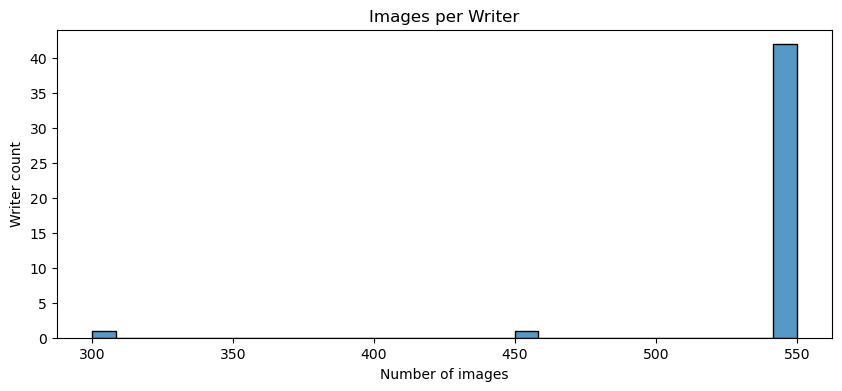

In [ ]:
# Sind die Klassen balanced oder imbalanced?
writer_counts = df.writer_id.value_counts()
print(writer_counts.head(10))

plt.figure(figsize=(10,4))
sns.histplot(writer_counts, bins=30)
plt.title("Images per Writer")
plt.xlabel("Number of images")
plt.ylabel("Writer count")
plt.show()

# Die Klassen sind weitgehend balanciert, da die meisten Writer etwa 550 Bilder haben
# Wenige Writer haben weniger als 550 Bilder 
# (vermutlich ein Writer: 300; ein anderer: 450)

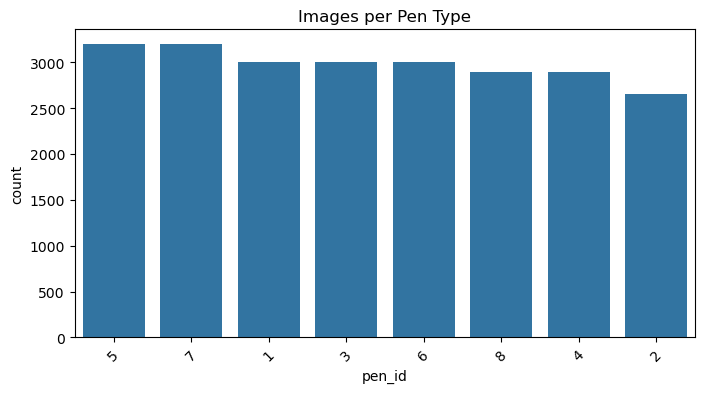

In [ ]:
# Verteilung der Pen Types
plt.figure(figsize=(8,4))
sns.countplot(data=df, x="pen_id", order=df.pen_id.value_counts().index)
plt.xticks(rotation=45)
plt.title("Images per Pen Type")
plt.show()

# Die Pen Types sind relativ gleichmäßig verteilt, da alle Stifte eine ähnliche Anzahl an Bildern haben
# Pen 2 haben weniger Samples aber im Großen und Ganzen ist die Verteilung der Pen Types recht ausgewogen

count     44.000000
mean     542.045455
std       40.265372
min      300.000000
25%      550.000000
50%      550.000000
75%      550.000000
max      550.000000
Name: count, dtype: float64


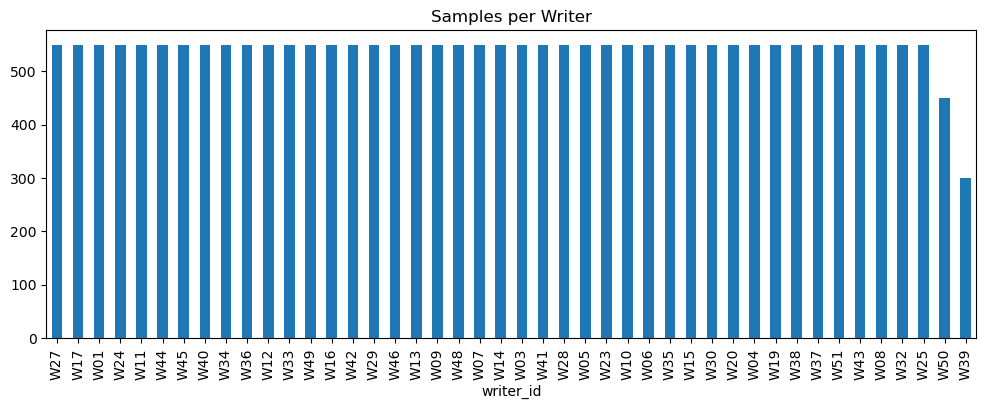

In [23]:
print(writer_counts.describe())
pd.crosstab(df.writer_id, df.pen_id) # Modell wird W39 schlechter erkennen
writer_counts.plot(kind="bar", figsize=(12,4))
plt.title("Samples per Writer")
plt.show()

# Die meisten Writer haben 550 Samples, wodurch die Klassen insgesamt sehr balanciert sind (siehe oben)
# Writer 50 hat nur 450 Samples, Writer 39 hat nur 300 Samples

In [10]:
image_dir = "Dataset/images/"
image_files = sorted([f for f in os.listdir(image_dir) if f.endswith(".png")])
sample_files = image_files[:1000]

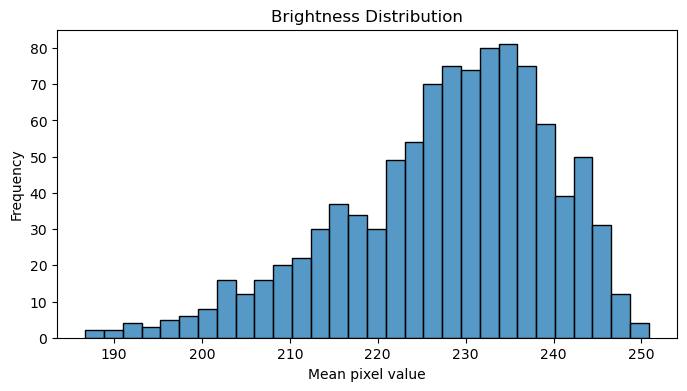

In [ ]:
brightness = []
for img_name in sample_files:
    img_path = os.path.join(image_dir, img_name)
    img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
    brightness.append(img.mean())

plt.figure(figsize=(8,4))
sns.histplot(brightness, bins=30)

plt.title("Brightness Distribution")
plt.xlabel("Mean pixel value")
plt.ylabel("Frequency")
plt.show()

# Helligkeitsverteilung ist relativ normalverteilt
# konzentriert sich um hohe Pixelwerte (~230), was darauf hindeutet, dass die meisten Bilder hell sind
# (Schlussfolgerung: die meisten Bilder haben einen weißen Hintergrund und dunkle Linien)

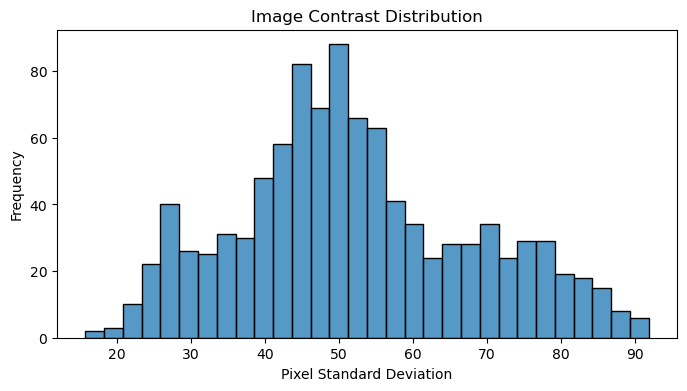

In [ ]:
# Kontrast über Standardabweichung der Pixelwerte messen
contrast = []
for img_name in sample_files:
    img_path = os.path.join(image_dir, img_name)
    img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
    contrast.append(img.std())

plt.figure(figsize=(8,4))
sns.histplot(contrast, bins=30)

plt.title("Image Contrast Distribution")
plt.xlabel("Pixel Standard Deviation")
plt.ylabel("Frequency")
plt.show()

# Die Kontrastwerte verteilen sich relativ breit, 
# mit einem Schwerpunkt etwa zwischen 40 und 60, 
# was auf moderate Unterschiede im Bildkontrast hinweist!
# Keine extremen Ausreißer -> Bildqualität größtenteils konsistent

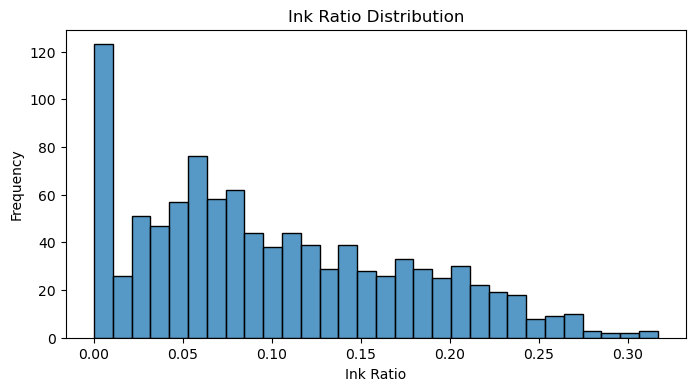

In [ ]:
# Anteil der Tintenpixel (Ink Ratio) - Ink Ratio = dunkle Pixel / Gesamtpixel
ink_ratio = []
for img_name in sample_files:
    img_path = os.path.join(image_dir, img_name)
    img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
    ink = np.sum(img < 128)
    ink_ratio.append(ink / img.size)

plt.figure(figsize=(8,4))
sns.histplot(ink_ratio, bins=30)
plt.title("Ink Ratio Distribution")
plt.xlabel("Ink Ratio")
plt.ylabel("Frequency")
plt.show()

# Ink Ratio ist meist relativ niedrig (0.03–0.15)
# gröter Teil aus Hintergrund besteht nur ein kleiner Anteil aus Tintenlinien
# Variation deutet auf unterschiedliche Schreibstile und Stiftdrücke hin 

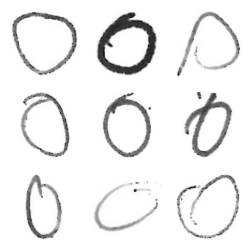

In [16]:
# Beispielbilder anzeigen
plt.figure(figsize=(3,3))
for i in range(9):
    img = cv2.imread(os.path.join(image_dir, image_files[i]), cv2.IMREAD_GRAYSCALE)
    plt.subplot(3,3,i+1)
    plt.imshow(img, cmap="gray")
    plt.axis("off")

plt.show()

In [ ]:
# Bildgröße überprüfen
sizes = []
for img_name in sample_files:
    img = Image.open(os.path.join(image_dir, img_name))    
    sizes.append(img.size)
sizes = np.array(sizes)
print("Unique sizes:", np.unique(sizes, axis=0))

Unique sizes: [[ 41  91]
 [ 44  80]
 [ 45  53]
 ...
 [191 141]
 [213 115]
 [229 172]]


In [ ]:
# Kreisposition prüfen
# Kreis immer mittig??

img = cv2.imread(os.path.join(image_dir, image_files[0]), cv2.IMREAD_GRAYSCALE)
ys, xs = np.where(img < 128)
xmin, xmax = xs.min(), xs.max()
ymin, ymax = ys.min(), ys.max()
print("Bounding box:", xmin, xmax, ymin, ymax)

# Bounding Box ist im Bereich [x: 4–96 und y: 3–94]
# damit nahe an den Bildrändern beginnt, 
# also nicht perfekt zentriert ist, aber auch leicht verschoben


Bounding box: 4 96 3 94


In [ ]:
# Radius-Variation (Kreis-Unregelmäßigkeit)
ys, xs = np.where(img < 128)
xc = xs.mean()
yc = ys.mean()
r = np.sqrt((xs-xc)**2 + (ys-yc)**2)

radius_std = r.std()
radius_mean = r.mean()

# Feature
print(radius_std)
print(radius_std / radius_mean)

# große Werte -> unruhige Hand
# kleine Werte -> stabiler Kreis


# Radius-Standardabweichung (~9.94) bzw. das Verhältnis (~0.25)
# Kreis nicht perfekt gleichmäßig gezeichnet 
# (gewisse Unruhe bzw. natürliche Handvariation beim Zeichnen)

9.937423389967845
0.25068679222886336


In [ ]:
# Linienstärke
# Stiftdruck und Stifttyp beeinflussen die Breite der Linie

_, binary = cv2.threshold(img, 128, 255, cv2.THRESH_BINARY_INV)
dist = cv2.distanceTransform(binary, cv2.DIST_L2, 5)
stroke_width_mean = dist[binary>0].mean()*2
stroke_width_std = dist[binary>0].std()*2

print("Mean stroke width:", stroke_width_mean)
print("Std stroke width:", stroke_width_std)

# durchschnittliche Linienstärke: 2.84 Pixeln
# moderate Variation (Std ≈ 1.12) -> relativ dünne, aber leicht variierende Linien
# Unterschiede durch Stifttyp oder Stiftdruck beim Zeichnen

Mean stroke width: 2.8445196
Std stroke width: 1.1189071


In [ ]:
# Form an einem perfekten Kreis

contours,_ = cv2.findContours(binary, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_NONE)
cnt = contours[0]
area = cv2.contourArea(cnt)
perimeter = cv2.arcLength(cnt, True)
circularity = 4*np.pi*area/(perimeter**2)
print(circularity) # perfekter Kreis hat Circularity = 1, unregelmäßiger Kreis < 1

# circularity deutlich unter 1
# abweichend gezeichneter Kreis weicht stark von einem perfekten Kreis ab

0.16122901320758615

In [ ]:
# Krümmungs-Variation (Curvature)
# Unruhige Hand -> mehr Variation
# Differenz der Radien entlang des Winkels

angles = np.arctan2(ys - yc, xs - xc)
curvature_var = np.var(angles)
print(curvature_var)

# hoher Krümmungsvariation -> unregelmäßige Linienführung 

np.float64(3.098258421922555)

In [ ]:
# feature_vector erstellen -> ML-Parameter

feature_vector = [
radius_mean,
radius_std,
stroke_width_mean,
stroke_width_std,
circularity,
curvature_var,
ink_ratio,
]

Dataset/images/


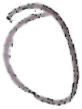

In [ ]:
path_variable = 'Dataset/images/'
print(path_variable)
img4 = Image.open(path_variable + "00004.png")
img5 = Image.open(path_variable + "00004.png")
img4

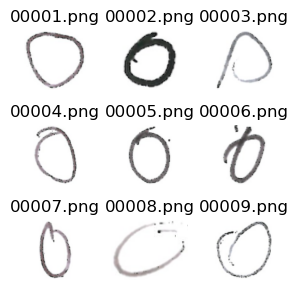

In [16]:
image_files = sorted([f for f in os.listdir(path_variable) if f.endswith(".png")])
image_files = image_files[:9]
fig, axes = plt.subplots(3, 3, figsize=(3, 3))

for ax, image_file in zip(axes.ravel(), image_files):
    img = Image.open(os.path.join(path_variable, image_file))
    ax.imshow(img)
    ax.set_title(image_file)
    ax.axis("off")

plt.tight_layout()
plt.show()

In [ ]:
# TBD für EDA:
# nach WriterID gruppieren und die Anzahl der Bilder pro WriterID visualisieren
# nach PenType gruppieren und die Anzahl der Bilder pro PenType visualisieren 
# haben alle WriterIDs die gleiche Anzahl an Bildern? (ggf. mit einem Boxplot visualisieren)


# TBD für Modellentscheidung:
# Wenn EDA zeigt, dass lokale Strichtextur dominiert -> CNN sehr sinnvoll
# Wenn EDA zeigt, dass globale Formabweichungen stark sind -> globale Shape-Features ergänzen
# Wenn EDA zeigt, dass Pen/Scan stark dominiert -> härtere Normalisierung und bessere Validation
# Wenn EDA zeigt, dass Writer intern sehr konsistent sind -> Metric Learning lohnt sich besonders
# Writerentscheidung mittels Radius / Größe des Kreises, Geschlossenheit, Krümmungsverlauf, Druck-/Tintenvariation --> CNNs
# 2D-Projektion einfacher Features oder vortrainierter Embeddings mittels PCA/t-SNE/UMAP visualisieren, um zu sehen, ob WriterIDs Cluster bilden oder ob es starke Überlappungen gibt


# Offene Fragen:
# Pro Writer zu wenige Bilder -> Datenaugmentation oder Few-Shot Learning nötig oder GAN-Bilder erstellen oder Up/Downsampling im Training?
# Bilder gleich groß?
# Wie stark variiert die Linienstärke?
# Ist der Kreis immer zentriert?
# Gibt es starke Unterschiede in Helligkeit/Kontrast? -> Histogramm stretching oder CLAHE als Vorverarbeitung?
# - Verteilung von Bildhöhe/Bildbreite, Verteilung von mittlerer Helligkeit, Verteilung von Kontrast / Standardabweichung der Pixel
# - ein Grid mit z. B. 50 zufälligen Bildern

In [ ]:
# neu strukturiert:

# Datensatz 
# - Klassenverteilung 
# - Sample-Zahl 
# - Splits
# - mögliche Leaks

# Bild
# - Auflösung
# - Helligkeit
# - Kontrast
# - Rand
# - Scanartefakte
# - Dicke / Position des Kreises

# Identitätssignal
# - intra-writer Konsistenz
# - inter-writer Unterschiede
# - pen-/scanbedingte Störfaktoren
# - unknown-Writer-Simulation